In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

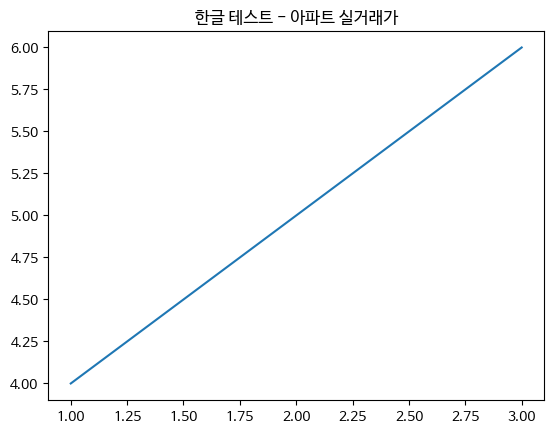

In [ ]:
import matplotlib.pyplot as plt

# 2. 나눔고딕 설정
plt.rc('font', family='NanumBarunGothic') # 보통 코랩에서는 'NanumBarunGothic'이 더 잘 잡힙니다.
plt.rcParams['axes.unicode_minus'] = False

# 테스트용 그래프
plt.title('한글 테스트 - 아파트 실거래가')
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 나눔 고딕 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

In [ ]:
df.describe()

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price
count,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06
mean,6.091530e+05,6.299685e+03,7.816549e+01,1.998297e+03,2.012984e+05,9.343291e+00,3.822769e+04
std,3.526198e+05,3.581169e+03,2.915113e+01,8.941347e+00,2.905732e+02,6.606500e+00,3.104898e+04
min,0.000000e+00,0.000000e+00,9.260000e+00,1.961000e+03,2.008010e+05,-4.000000e+00,1.000000e+02
25%,3.041380e+05,3.345000e+03,5.976000e+01,1.993000e+03,2.010100e+05,4.000000e+00,1.900000e+04
50%,6.082760e+05,5.964000e+03,8.241000e+01,1.999000e+03,2.013120e+05,8.000000e+00,3.090000e+04
75%,9.124140e+05,9.436000e+03,8.497000e+01,2.005000e+03,2.015110e+05,1.300000e+01,4.700000e+04
max,1.234827e+06,1.265800e+04,4.243200e+02,2.017000e+03,2.017110e+05,8.000000e+01,8.200000e+05


In [ ]:
# 새로운 독립변수 설정 - 아파트 연식

# 거래 당시 기준 연식 계산 (아파트 거래년도 - 건축 완공연도)
df['transaction_year'] = df['transaction_year_month'].apply(lambda x: int(str(x)[:4]))
df['building_age'] = df['transaction_year'] - df['year_of_completion']

def age_group(age):
  if age <= 5:
    return 'new'
  elif age <= 10:
    return 'semi-new'
  else:
    return 'old'

df['building_age_group'] = df['building_age'].apply(age_group)


In [ ]:
# 새로운 데이터프레임 저장

df_final = df.copy()

df_final = df_final.drop(columns=['year_of_completion'])

# year_of_completion이 없어졌는지 확인
df_final.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,transaction_year_month,transaction_date,floor,transaction_real_price,transaction_year,building_age,building_age_group
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,200801,21~31,2,37500,2008,6,semi-new
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,200801,1~10,6,20000,2008,35,old


In [ ]:
# 1. 불필요한 변수 삭제 + 문자열로 된 데이터 제거 (bec 선형회귀모델은 문자형 불가능하기 때문)
df_final = df_final.drop(columns=[
    'transaction_id',
    'apartment_id',
    'transaction_date',
    'addr_kr',
    'jibun',
    'apt',], errors='ignore')

# 2. city + dong -> One-Hot Encoding
df_final = pd.get_dummies(df_final, columns=['city', 'dong'], drop_first=True)

# 3. 위에서 만든 연식 -> Label Encoding
import numpy as np
from sklearn.preprocessing import LabelEncoder

encoder_age = LabelEncoder()

# 순서 지정: old = 0, semi-new = 1, new = 2
encoder_age.classes_ = np.array(['old', 'semi-new', 'new'])
df_final['building_age_encoded'] = encoder_age.transform(df_final['building_age_group'])

# 이미 인코딩 완료된 이전 데이터들 제거
df_final = df_final.drop(columns=['building_age_group', 'building_age'], errors='ignore')

# 확인
print(df_final.shape)
df_final.head()

(1216553, 479)


,exclusive_use_area,transaction_year_month,floor,transaction_real_price,transaction_year,city_서울특별시,dong_가리봉동,dong_가산동,dong_가야동,dong_가양동,...,dong_회동동,dong_회현동1가,dong_회현동2가,dong_효제동,dong_효창동,dong_후암동,dong_휘경동,dong_흑석동,dong_흥인동,building_age_encoded
0,84.82,200801,2,37500,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
1,99.17,200801,6,20000,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
2,84.74,200801,6,38500,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
3,146.39,200801,15,118000,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
4,194.43,200801,3,120000,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2


In [ ]:
# 스케일링 (표준화)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['exclusive_use_area', 'floor']
df_final[cols] = scaler.fit_transform(df_final[cols])

print(df_final[cols].head())

   exclusive_use_area     floor
0            0.228276 -1.111526
1            0.720539 -0.506061
2            0.225532 -0.506061
3            2.340374  0.856234
4            3.988338 -0.960159


In [ ]:
df_final.head()

,exclusive_use_area,transaction_year_month,floor,transaction_real_price,transaction_year,city_서울특별시,dong_가리봉동,dong_가산동,dong_가야동,dong_가양동,...,dong_회동동,dong_회현동1가,dong_회현동2가,dong_효제동,dong_효창동,dong_후암동,dong_휘경동,dong_흑석동,dong_흥인동,building_age_encoded
0,0.228276,200801,-1.111526,37500,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
1,0.720539,200801,-0.506061,20000,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
2,0.225532,200801,-0.506061,38500,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
3,2.340374,200801,0.856234,118000,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
4,3.988338,200801,-0.960159,120000,2008,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2


In [ ]:
# 구글 Colab RAM이 100만개 데이터를 못 견뎌서 전체 데이터의 20%만 갖고와서 학습 진행
df_final = df_final.sample(frac=0.2, random_state=0)

In [ ]:
# X, y 분리

# 타겟 변수: 집 값
y = df_final['transaction_real_price']

# 독립 변수: 나머지 전부
X = df_final.drop(columns=['transaction_real_price'])

print(X.shape)
print(y.shape)

X.head()

(243311, 478)
(243311,)


,exclusive_use_area,transaction_year_month,floor,transaction_year,city_서울특별시,dong_가리봉동,dong_가산동,dong_가야동,dong_가양동,dong_갈월동,...,dong_회동동,dong_회현동1가,dong_회현동2가,dong_효제동,dong_효창동,dong_후암동,dong_휘경동,dong_흑석동,dong_흥인동,building_age_encoded
156067,-0.968247,201107,-0.203329,2011,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
935579,-0.227281,201101,-0.808793,2011,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
1215094,-0.223164,201711,-0.506061,2017,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
207951,-0.691414,201309,-0.960159,2013,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
934903,-0.772715,201012,-0.657427,2010,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0


In [ ]:
# train / test 분리

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (194648, 478)
X_test shape: (48663, 478)
y_train shape: (194648,)
y_test shape: (48663,)


In [ ]:
# LinearRegression estimator 사용해서 예측 수행

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# fit 이용해서 모델 학습
estimator = LinearRegression()
estimator.fit(X_train, y_train)

# predict 이용해서 예측
y_pred = estimator.predict(X_test)

# 실제값 vs 예측값
print('실제값:', y_test[:3].values)
print('예측값:', y_pred[:3])

# 모델 성능 평가
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'\nRMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

실제값: [25500 25000 13500]
예측값: [25159.25974657 19155.72212532 10231.10442714]

RMSE: 14128.90
R²: 0.7937


In [ ]:
# K-Fold 이용한 교차검증

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
import numpy as np

# 데이터 준비
features = X.values
label = y.values

# 모델 설정
lr_reg = LinearRegression()

# K-Fold 설정 (5등분)
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

rmse_list = []
r2_list = []

print('데이터 개수:', features.shape[0])

n_iter = 0

# K-Fold 진행
for train_index, test_index in kfold.split(features):

    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    # 학습 (선형 회귀 모델 학습)
    lr_reg.fit(X_train, y_train)

    # 예측
    pred = lr_reg.predict(X_test)

    n_iter += 1

    # 평가
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"#{n_iter} RMSE: {rmse:.2f}, R2: {r2:.4f}")

    rmse_list.append(rmse)
    r2_list.append(r2)

# 평균 성능 산출
print(f"## [Linear Regression] 평균 RMSE: {np.mean(rmse_list):.2f}")
print(f"## [Linear Regression] 평균 R2: {np.mean(r2_list):.4f}")

데이터 개수: 243311
#1 RMSE: 14128.90, R2: 0.7937
#2 RMSE: 13954.88, R2: 0.8017
#3 RMSE: 14163.20, R2: 0.7958
#4 RMSE: 13892.05, R2: 0.8016
#5 RMSE: 14316.67, R2: 0.7980
## [Linear Regression] 평균 RMSE: 14091.14
## [Linear Regression] 평균 R2: 0.7981


In [ ]:
# GridSearchCV 진행

from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd

X_train, X_test, Y_train, Y_test = train_test_split(features, label, test_size=0.2, random_state=0)

# 파라미터 설정
parameters = {'fit_intercept': [True, False]}

# GridSearchCV 설정
grid_lr = GridSearchCV(
    lr_reg,
    param_grid=parameters,
    cv=3,
    refit=True
)
grid_lr.fit(X_train, Y_train)

# 결과 확인
scores_df = pd.DataFrame(grid_lr.cv_results_)
print("- GridSearchCV 탐색 결과 -")
display(scores_df[['params', 'mean_test_score', 'rank_test_score']])

# 최적 파라미터 & 최고 성능
print('\n최적 파라미터:', grid_lr.best_params_)
print('최고 R2 점수(CV): {:.3f}'.format(grid_lr.best_score_))

- GridSearchCV 탐색 결과 -


,params,mean_test_score,rank_test_score
0,{'fit_intercept': True},0.798968,1
1,{'fit_intercept': False},0.782246,2



최적 파라미터: {'fit_intercept': True}
최고 R2 점수(CV): 0.7990
